<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/CICIoT2023_himadri_TabM_RealMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
DO_MOUNT_DRIVE   = True
DO_DOWNLOAD      = True

DATASET_ID       = 'himadri07/ciciot2023'
DRIVE_CACHE      = '/content/drive/MyDrive/kagglehub_cache'
DRIVE_OUT_DIR    = '/content/drive/MyDrive/ciciot2023_himadri_outputs'

LABEL_COL        = 'label'
UNDERSAMPLE_TO   = 12_000
MIN_CLASS_SIZE   = 500
RANDOM_STATE     = 42
DEVICE           = 'cuda'

N_EPOCHS_TABM    = 256
EARLY_STOPPING   = 256
BATCH_SIZE       = 512

In [26]:
# CELL 2 — INSTALL


!pip install -q pytabkit
!pip install -q tabm
!pip install -q kagglehub
!pip install -q scikit-learn pandas numpy matplotlib seaborn
print(' All packages installed restart runtime')

 All packages installed  now restart runtime!


In [27]:
# CELL 3 — IMPORTS + MOUNT + DOWNLOAD + GPU CHECK

import os, glob, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from pytabkit import RealMLP_TD_Classifier
warnings.filterwarnings('ignore')

if not torch.cuda.is_available():
    raise RuntimeError('\n\n NO GPU! - Runtime - Change runtime type - T4 GPU\n')
device = torch.device(DEVICE)
print(f' GPU: {torch.cuda.get_device_name(0)}')

if DO_MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    print(' Drive mounted')

if DO_DOWNLOAD:
    import kagglehub
    os.makedirs(DRIVE_CACHE, exist_ok=True)
    os.environ['KAGGLE_CACHE_DIR'] = DRIVE_CACHE
    print('Downloading CICIoT2023 (himadri07)...')
    path = kagglehub.dataset_download(DATASET_ID)
    print(f' Downloaded to: {path}')
    data_dir = path
else:
    base = os.path.join(DRIVE_CACHE, 'datasets',
                        DATASET_ID.split('/')[0], DATASET_ID.split('/')[1])
    if os.path.exists(base):
        versions = sorted([d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))])
        data_dir = os.path.join(base, versions[-1]) if versions else base
    else:
        data_dir = base
    print(f' Using cached data: {data_dir}')

# Adjust data_dir to point to the actual CSV files location within the dataset
data_dir = os.path.join(data_dir, 'CICIOT23', 'validation')

print(f' Output dir: {DRIVE_OUT_DIR}')

 GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted
Using Colab cache for faster access to the 'ciciot2023' dataset.
 Downloaded to: /kaggle/input/ciciot2023
 Output dir: /content/drive/MyDrive/ciciot2023_himadri_outputs


In [28]:
# CELL 4 — LOAD ALL CSVs

csv_files = sorted(glob.glob(os.path.join(data_dir, '**/*.csv'), recursive=True))
print(f'Found {len(csv_files)} CSV files:')
total_size = 0
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    total_size += size_mb
    print(f'  {os.path.basename(f):40s} ({size_mb:.1f} MB)')
print(f'Total size: {total_size/1024:.2f} GB')

print(f'\nLoading all files...')
start = time.time()
dfs = []
for i, f in enumerate(csv_files):
    try:
        chunk = pd.read_csv(f, low_memory=False)
        chunk.columns = chunk.columns.str.strip()
        dfs.append(chunk)
        print(f'  Loaded {i+1}/{len(csv_files)}: {os.path.basename(f)} ({len(chunk):,} rows)')
    except Exception as e:
        print(f'   Skipped {os.path.basename(f)}: {e}')

df = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

df.columns = df.columns.str.strip()
elapsed = time.time() - start
print(f'\n Loaded in {elapsed:.1f}s')
print(f'Total shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'\nColumns: {list(df.columns)}')

# Auto-detect label column
possible_labels = ['label', 'Label', 'LABEL', 'attack', 'Attack',
                   'type', 'Type', 'class', 'Class', 'category']
for pl in possible_labels:
    if pl in df.columns:
        LABEL_COL = pl
        break

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
print(f'\nLabel column: "{LABEL_COL}"')
print(f'\nLabel distribution ({df[LABEL_COL].nunique()} classes):')
counts = df[LABEL_COL].value_counts()
for lbl, cnt in counts.items():
    pct = cnt / len(df) * 100
    print(f'  {lbl:40s} {cnt:>12,}  ({pct:.2f}%)')

Found 1 CSV files:
  validation.csv                           (331.8 MB)
Total size: 0.32 GB

Loading all files...
  Loaded 1/1: validation.csv (1,176,851 rows)

 Loaded in 8.8s
Total shape: 1,176,851 rows x 47 cols

Columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Label column: "label"

Label distribution (34 classes):
  DDoS-ICMP_Flood                               182,011  (15.47%)
  DDoS-UDP_Flood                                136,466  (11.60%)
  DDoS-TCP_Flood                                113,888

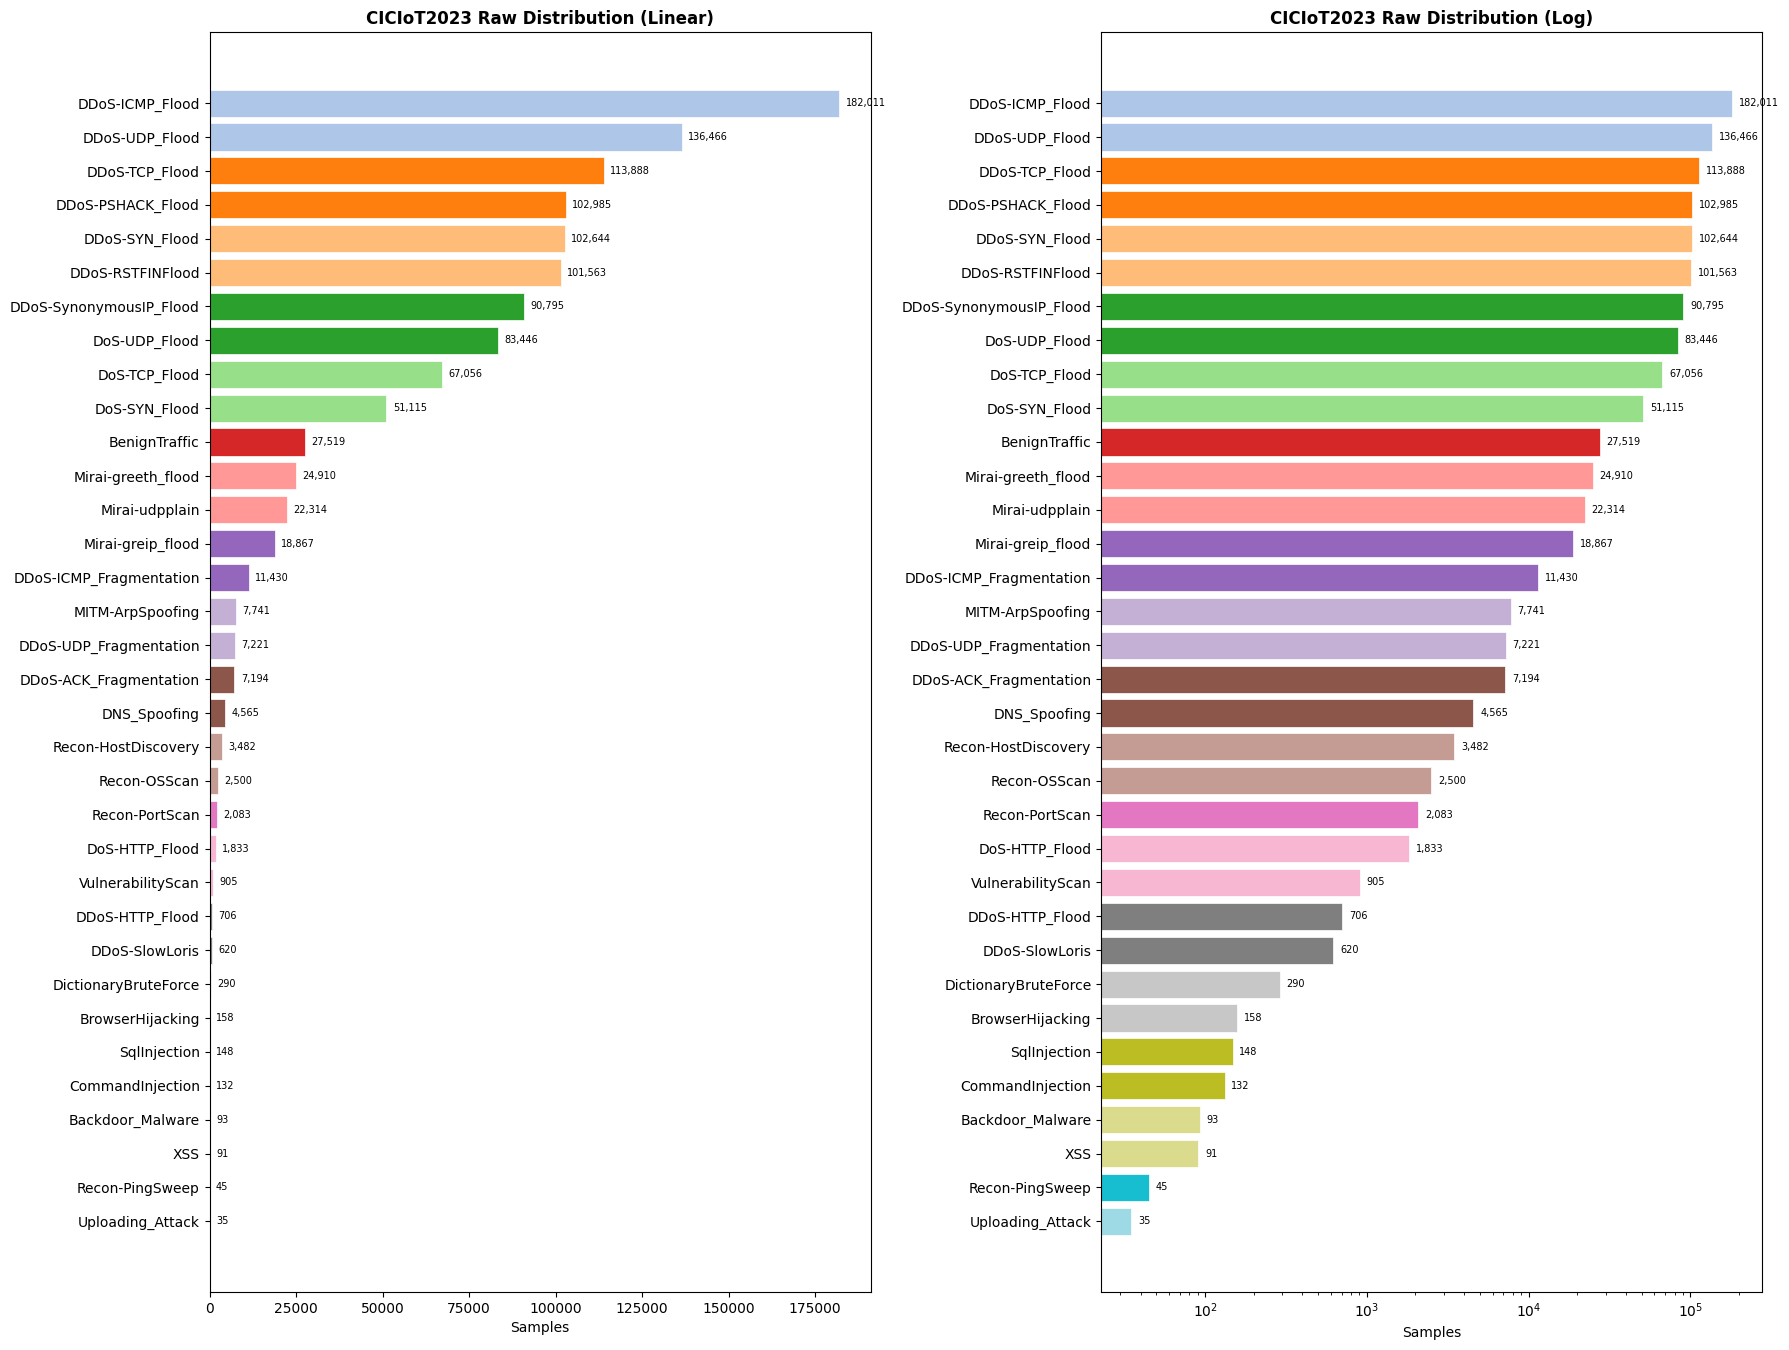

In [29]:
# CELL 5 — VISUALISE RAW DISTRIBUTION

counts = df[LABEL_COL].value_counts()
n = len(counts)

fig, axes = plt.subplots(1, 2, figsize=(18, max(7, n * 0.4)))

palette = []
atk_colors = list(plt.cm.tab20(np.linspace(0.05, 0.95, n)))
ai = 0
for lbl in counts.index:
    if str(lbl).lower() in ['benign', 'normal', 'benign traffic']:
        palette.append('#2ecc71')
    else:
        palette.append(atk_colors[ai])
        ai += 1

for ax, scale in zip(axes, ['linear', 'log']):
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=palette[::-1], edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Samples')
    ax.set_title(f'CICIoT2023 Raw Distribution ({scale.title()})', fontweight='bold')
    if scale == 'log':
        ax.set_xscale('log')
    for bar, count in zip(bars, counts.values[::-1]):
        x_pos = bar.get_width() * 1.1 if scale == 'log' else bar.get_width() + max(counts) * 0.01
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, 'raw_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# CELL 6 — UNDERSAMPLE + PREPROCESS

class_counts = df[LABEL_COL].value_counts()

valid_classes = class_counts[class_counts >= MIN_CLASS_SIZE].index.tolist()
dropped_classes = class_counts[class_counts < MIN_CLASS_SIZE].index.tolist()

if dropped_classes:
    print(f' Dropping {len(dropped_classes)} classes with < {MIN_CLASS_SIZE} samples:')
    for c in dropped_classes:
        print(f'  {c}: {class_counts[c]:,}')
    df = df[df[LABEL_COL].isin(valid_classes)].reset_index(drop=True)

class_counts = df[LABEL_COL].value_counts()
print(f'\nUndersampling each class to max {UNDERSAMPLE_TO:,}')
print(f'Keeping {len(valid_classes)} classes')

df_balanced = (
    df.groupby(LABEL_COL)
    .apply(lambda x: x.sample(min(len(x), UNDERSAMPLE_TO), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

del df
gc.collect()

print(f'\n Balanced: {len(df_balanced):,} rows')
print(df_balanced[LABEL_COL].value_counts())

obj_cols = df_balanced.select_dtypes(include='object').columns.tolist()
cols_to_drop = [c for c in obj_cols if c != LABEL_COL]
print(f'\nDropping non-numeric columns: {cols_to_drop}')

X_raw = df_balanced.drop(columns=[LABEL_COL] + cols_to_drop)
X_raw = X_raw.select_dtypes(include=[np.number])
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
y_raw = df_balanced[LABEL_COL].copy()

del df_balanced
gc.collect()

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print(f'\nClasses ({n_classes}): {list(le.classes_)}')
print(f'Features: {X_raw.shape[1]}')

# Split: 70/10/20
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=RANDOM_STATE, stratify=y_temp)

del X_raw, X_temp, y_temp
gc.collect()

total = len(y_train) + len(y_val) + len(y_test)
print(f'\nSplit:')
print(f'  Train : {len(X_train):,} ({len(X_train)/total*100:.1f}%)')
print(f'  Val   : {len(X_val):,}   ({len(X_val)/total*100:.1f}%)')
print(f'  Test  : {len(X_test):,}  ({len(X_test)/total*100:.1f}%)')

train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

del X_train, X_val, X_test
gc.collect()

n_features = X_train_s.shape[1]
print(f'\nFeatures after preprocessing: {n_features}')
print(' Preprocessing complete')

 Dropping 8 classes with < 500 samples:
  DictionaryBruteForce: 290
  BrowserHijacking: 158
  SqlInjection: 148
  CommandInjection: 132
  Backdoor_Malware: 93
  XSS: 91
  Recon-PingSweep: 45
  Uploading_Attack: 35

Undersampling each class to max 12,000
Keeping 26 classes

 Balanced: 218,280 rows
label
BenignTraffic              12000
DDoS-ICMP_Flood            12000
DDoS-SynonymousIP_Flood    12000
DDoS-PSHACK_Flood          12000
DDoS-SYN_Flood             12000
DDoS-RSTFINFlood           12000
DoS-SYN_Flood              12000
DoS-TCP_Flood              12000
DDoS-UDP_Flood             12000
DDoS-TCP_Flood             12000
DoS-UDP_Flood              12000
Mirai-udpplain             12000
Mirai-greip_flood          12000
Mirai-greeth_flood         12000
DDoS-ICMP_Fragmentation    11430
MITM-ArpSpoofing            7741
DDoS-UDP_Fragmentation      7221
DDoS-ACK_Fragmentation      7194
DNS_Spoofing                4565
Recon-HostDiscovery         3482
Recon-OSScan                2500
Rec

In [31]:
# CELL 7 — EVALUATION HELPER

def evaluate_model(model_name, y_true, y_pred, out_dir):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f'  {model_name} — Results')
    print(f"{'='*55}")
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  F1 (macro)    : {f1m:.4f}')
    print(f'  F1 (weighted) : {f1w:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)}')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'f1_macro': f1m, 'f1_weighted': f1w}

In [32]:
# CELL 8 — TRAIN TabM

from tabm import TabM

train_dl = DataLoader(
    TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(
    TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

tabm_model = TabM.make(
    n_num_features=n_features, cat_cardinalities=[], d_out=n_classes
).to(device)

optimizer = torch.optim.AdamW(tabm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print(f'TabM params: {sum(p.numel() for p in tabm_model.parameters()):,}')
print(f'Training TabM on CICIoT2023...')

best_val_f1, best_state, tabm_history, no_improve = 0, None, [], 0

for epoch in range(1, N_EPOCHS_TABM + 1):
    tabm_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(tabm_model(xb).mean(dim=1), yb).backward()
        optimizer.step()

    tabm_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            p = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
            preds_all.extend(p)
            true_all.extend(yb.numpy())

    val_f1  = f1_score(true_all, preds_all, average='macro', zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    tabm_history.append({'epoch': epoch, 'val_f1': val_f1, 'val_acc': val_acc})

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:03d}/{N_EPOCHS_TABM} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | No improve: {no_improve}/{EARLY_STOPPING}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu() for k, v in tabm_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOPPING:
            print(f'\n Early stopping at epoch {epoch}')
            break

print(f'\nBest Val F1 (TabM): {best_val_f1:.4f} ')

TabM params: 1,107,200
Training TabM on CICIoT2023...
  Epoch 001/256 | Acc: 0.7564 | F1: 0.6866 | No improve: 0/256
  Epoch 010/256 | Acc: 0.8132 | F1: 0.7632 | No improve: 0/256
  Epoch 020/256 | Acc: 0.9424 | F1: 0.8776 | No improve: 2/256
  Epoch 030/256 | Acc: 0.9451 | F1: 0.8830 | No improve: 1/256
  Epoch 040/256 | Acc: 0.9464 | F1: 0.8913 | No improve: 0/256
  Epoch 050/256 | Acc: 0.9452 | F1: 0.8863 | No improve: 9/256
  Epoch 060/256 | Acc: 0.9464 | F1: 0.8889 | No improve: 2/256
  Epoch 070/256 | Acc: 0.9458 | F1: 0.8910 | No improve: 12/256
  Epoch 080/256 | Acc: 0.9450 | F1: 0.8854 | No improve: 22/256
  Epoch 090/256 | Acc: 0.9444 | F1: 0.8867 | No improve: 32/256
  Epoch 100/256 | Acc: 0.9458 | F1: 0.8875 | No improve: 42/256
  Epoch 110/256 | Acc: 0.9435 | F1: 0.8837 | No improve: 52/256
  Epoch 120/256 | Acc: 0.9459 | F1: 0.8863 | No improve: 62/256
  Epoch 130/256 | Acc: 0.9442 | F1: 0.8853 | No improve: 72/256
  Epoch 140/256 | Acc: 0.9451 | F1: 0.8860 | No improve: 

TabM | Train | Acc: 0.9762 | F1: 0.9538

  TabM — Results
  Accuracy      : 0.9468
  F1 (macro)    : 0.8866
  F1 (weighted) : 0.9455

                         precision    recall  f1-score   support

          BenignTraffic       0.76      0.87      0.81      2400
 DDoS-ACK_Fragmentation       0.98      0.99      0.98      1439
        DDoS-HTTP_Flood       0.92      0.95      0.94       141
        DDoS-ICMP_Flood       1.00      1.00      1.00      2400
DDoS-ICMP_Fragmentation       0.99      0.99      0.99      2286
      DDoS-PSHACK_Flood       1.00      1.00      1.00      2400
       DDoS-RSTFINFlood       1.00      1.00      1.00      2400
         DDoS-SYN_Flood       1.00      1.00      1.00      2400
         DDoS-SlowLoris       0.80      0.86      0.83       124
DDoS-SynonymousIP_Flood       1.00      1.00      1.00      2400
         DDoS-TCP_Flood       1.00      1.00      1.00      2400
         DDoS-UDP_Flood       1.00      1.00      1.00      2400
 DDoS-UDP_Fragmentat

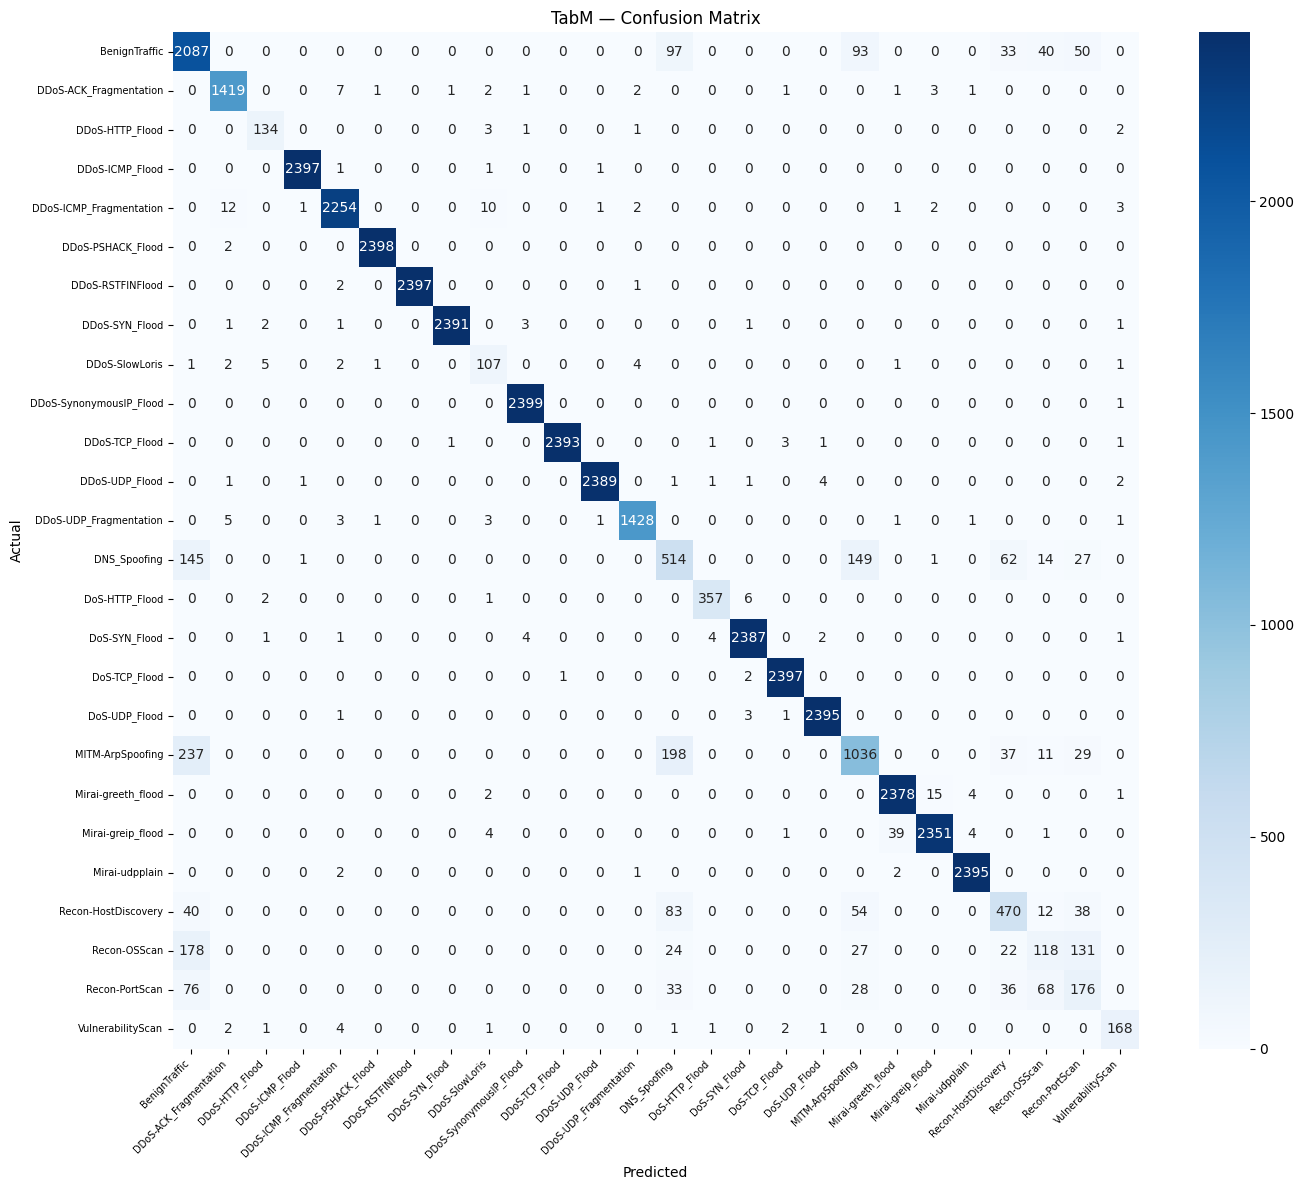

In [33]:
# CELL 9 — EVALUATE TabM

tabm_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tabm_model.eval()

test_dl = DataLoader(
    TensorDataset(torch.tensor(X_test_s), torch.tensor(y_test, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

preds_all, true_all = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        p = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
        preds_all.extend(p)
        true_all.extend(yb.numpy())

train_dl_eval = DataLoader(
    TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)
train_preds = []
with torch.no_grad():
    for xb, yb in train_dl_eval:
        p = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
        train_preds.extend(p)

train_acc = accuracy_score(y_train, train_preds)
train_f1  = f1_score(y_train, train_preds, average='macro', zero_division=0)
print(f'TabM | Train | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')

tabm_results = evaluate_model('TabM', true_all, preds_all, DRIVE_OUT_DIR)
tabm_results['train_acc'] = train_acc
tabm_results['train_f1']  = train_f1

In [34]:
# CELL 10 — TRAIN RealMLP

print('Training RealMLP on CICIoT2023...')
realmlp = RealMLP_TD_Classifier(
    device='cuda', random_state=RANDOM_STATE, verbosity=1, n_cv=1, n_refit=0)
realmlp.fit(X_train_s, y_train, X_val=X_val_s, y_val=y_val)
print(' RealMLP training complete')

Training RealMLP on CICIoT2023...
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]
Columns classified as categorical: []


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=256` reached.


 RealMLP training complete


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud

RealMLP | Train | Acc: 0.9624 | F1: 0.9227

  RealMLP — Results
  Accuracy      : 0.9509
  F1 (macro)    : 0.8977
  F1 (weighted) : 0.9488

                         precision    recall  f1-score   support

          BenignTraffic       0.71      0.87      0.78      2400
 DDoS-ACK_Fragmentation       1.00      1.00      1.00      1439
        DDoS-HTTP_Flood       0.97      0.98      0.97       141
        DDoS-ICMP_Flood       1.00      1.00      1.00      2400
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      2286
      DDoS-PSHACK_Flood       1.00      1.00      1.00      2400
       DDoS-RSTFINFlood       1.00      1.00      1.00      2400
         DDoS-SYN_Flood       1.00      1.00      1.00      2400
         DDoS-SlowLoris       0.94      0.96      0.95       124
DDoS-SynonymousIP_Flood       1.00      1.00      1.00      2400
         DDoS-TCP_Flood       1.00      1.00      1.00      2400
         DDoS-UDP_Flood       1.00      1.00      1.00      2400
 DDoS-UDP_Frag

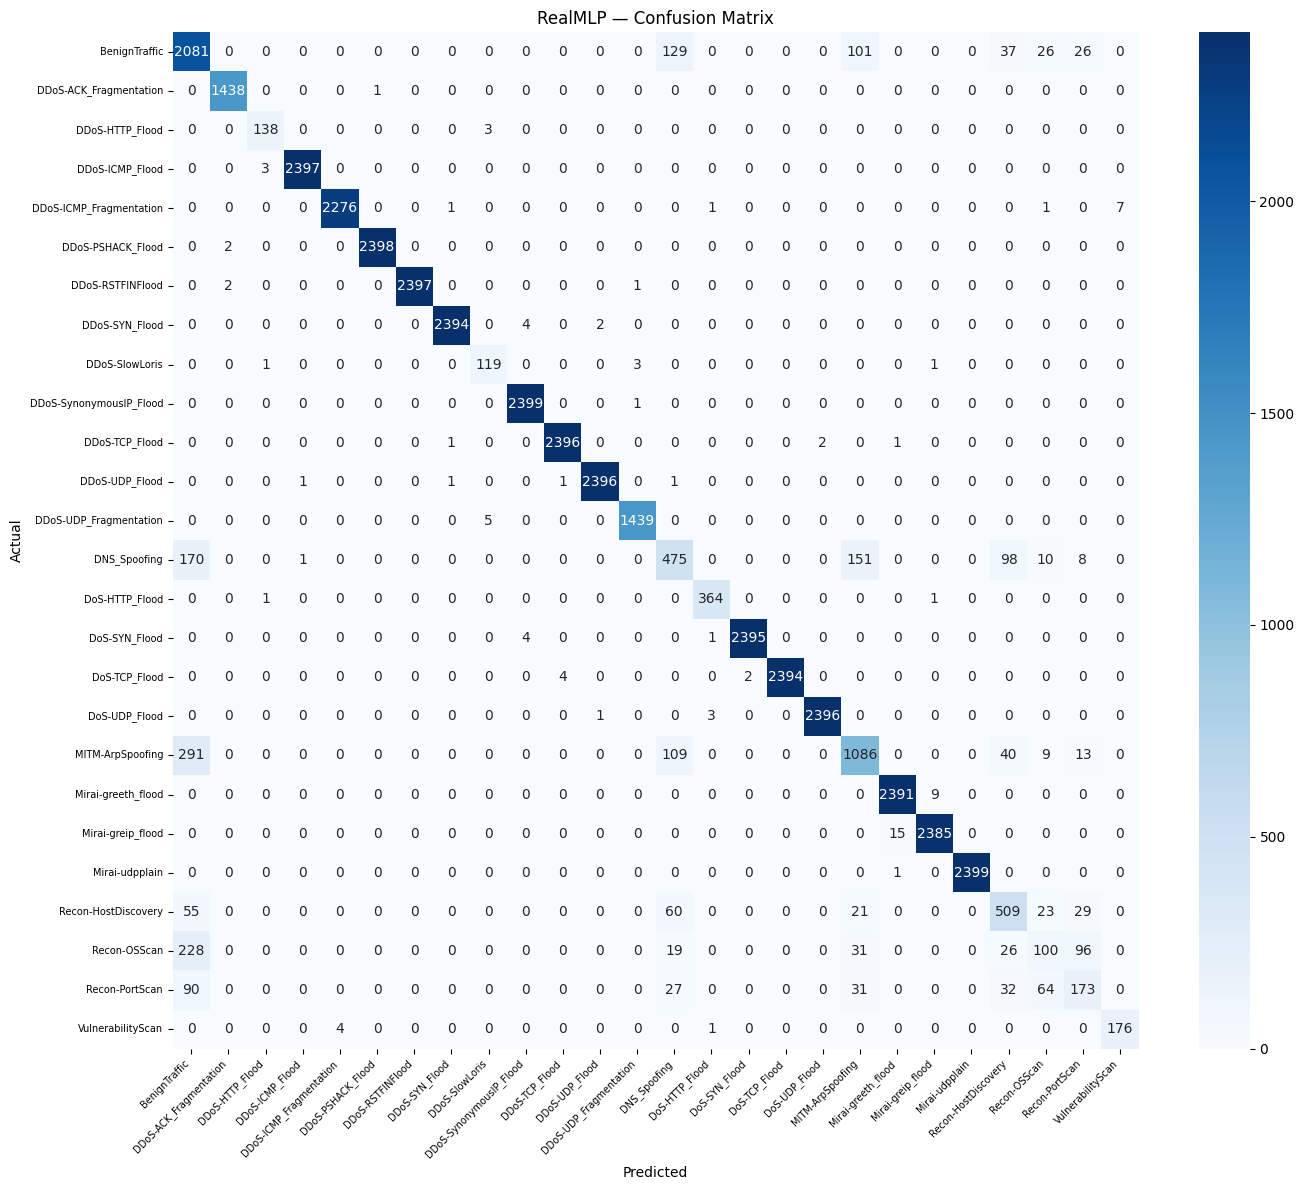

In [35]:
# CELL 11 — EVALUATE RealMLP

realmlp_train_preds = realmlp.predict(X_train_s)
train_acc = accuracy_score(y_train, realmlp_train_preds)
train_f1  = f1_score(y_train, realmlp_train_preds, average='macro', zero_division=0)
print(f'RealMLP | Train | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')

realmlp_test_preds = realmlp.predict(X_test_s)
realmlp_results = evaluate_model('RealMLP', y_test, realmlp_test_preds, DRIVE_OUT_DIR)
realmlp_results['train_acc'] = train_acc
realmlp_results['train_f1']  = train_f1


===== FINAL RESULTS — CICIoT2023 =====
  model  train_acc  accuracy  train_f1  f1_macro  f1_weighted
   TabM   0.976164  0.946834  0.953825  0.886611     0.945541
RealMLP   0.962407  0.950866  0.922663  0.897720     0.948754

Results saved: /content/drive/MyDrive/ciciot2023_himadri_outputs/ciciot2023_results.csv


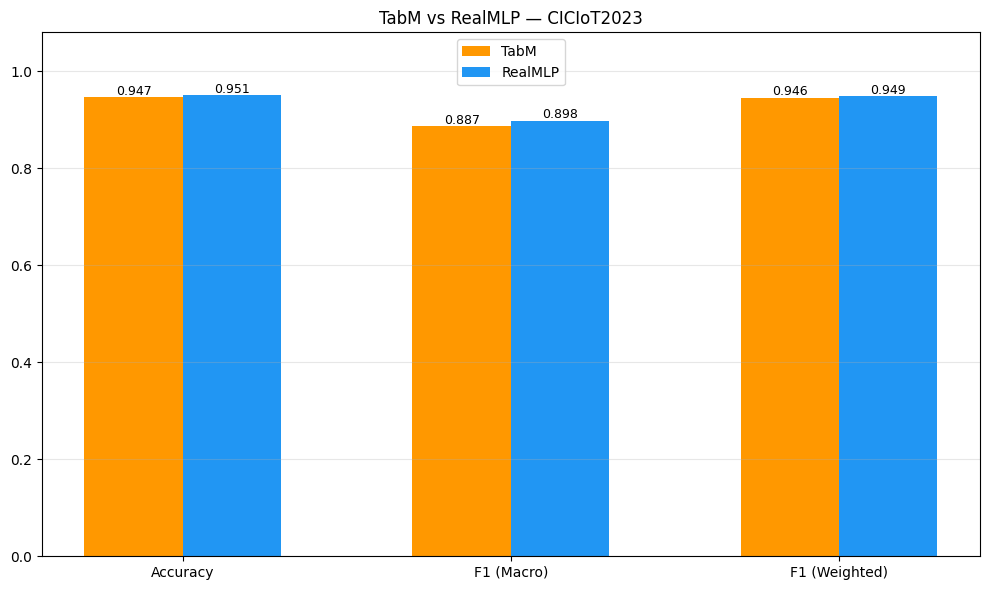

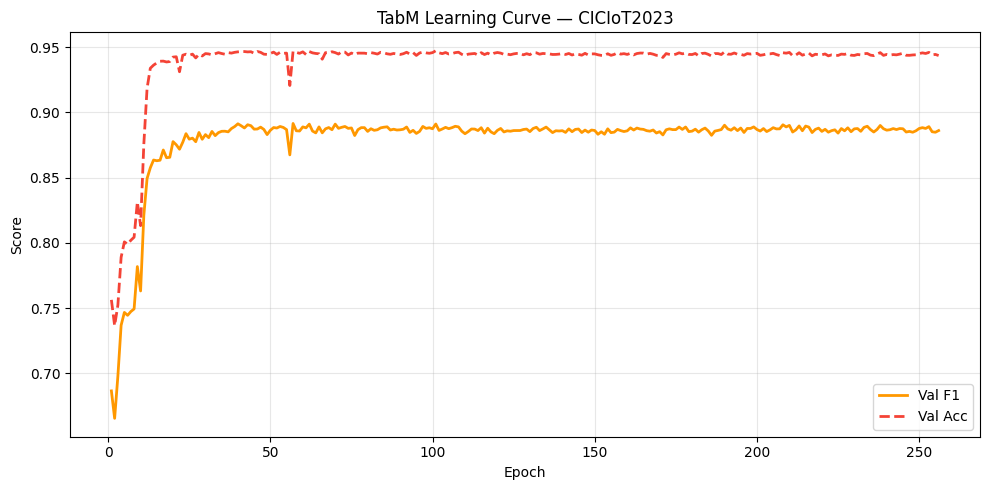


 All outputs saved to Drive!


In [36]:
# CELL 12 — COMPARISON + SAVE

results_df = pd.DataFrame([tabm_results, realmlp_results])
print('\n===== FINAL RESULTS — CICIoT2023 =====')
print(results_df[['model', 'train_acc', 'accuracy',
                   'train_f1', 'f1_macro', 'f1_weighted']].to_string(index=False))

csv_path = os.path.join(DRIVE_OUT_DIR, 'ciciot2023_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nResults saved: {csv_path}')

# Comparison chart
metrics = ['accuracy', 'f1_macro', 'f1_weighted']
metric_names = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
x, width = np.arange(len(metrics)), 0.3

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, [tabm_results[m] for m in metrics], width,
            label='TabM', color='#FF9800')
b2 = ax.bar(x + width/2, [realmlp_results[m] for m in metrics], width,
            label='RealMLP', color='#2196F3')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.08)
ax.set_title('TabM vs RealMLP — CICIoT2023')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, 'comparison.png'), dpi=150)
plt.show()

# TabM learning curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([h['epoch'] for h in tabm_history], [h['val_f1'] for h in tabm_history],
        label='Val F1', color='#FF9800', linewidth=2)
ax.plot([h['epoch'] for h in tabm_history], [h['val_acc'] for h in tabm_history],
        label='Val Acc', color='#F44336', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('TabM Learning Curve — CICIoT2023')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, 'tabm_curve.png'), dpi=150)
plt.show()

print('\n All outputs saved to Drive!')